# Dataset feature extractor
## Introdução
### Código
Importa arquivos de um dataset e realiza procedimento adotado por (Zhang, Zhu, Shen, 2018) [1]. Em que respostas impulsivas são classificadas em termos das primeiras reflexões. A primeira reflexão é determinada utilizando método proposto por (Usher, 2010) [2], em que é utilizado um algoritmo de curtose com janela deslizante adaptado para detecção de picos. 

Para a análise de clusters, utiliza-se uma região de 60 ms para análise, iniciando na primeira reflexão, referente ao som direto da sala, e os 60 ms subsequentes.

<!-- Espera-se que os *clusters*, apesar de serem analisados no domínio temporal, se aglomerem espacialmente, como observado no *paper* original [1]. -->

### Referências:
[1] Zhang, Z., Zhu, G., & Shen, Y. (2018). Data clustering analysis of early reflections in small room. *The Journal of the Acoustical Society of America, 144*(4), EL328–EL332. [https://doi.org/10.1121/1.5065073](https://doi.org/10.1121/1.5065073)

[2] Usher, J. (2010). An improved method to determine the onset timings of reflections in an acoustic impulse response. *The Journal of the Acoustical Society of America, 127*(4), EL172–EL177. [https://doi.org/10.1121/1.3361042](https://doi.org/10.1121/1.3361042)


In [29]:
import numpy as np
import yk_funcs as ykk
import h5py as h5
import matplotlib.pyplot as plt

## Dataset import
O conjunto de dados bruto é grande demais para caber no github(\~200 MiB), no entanto, salvarei no repositório o conjunto de dados com *features* extraidas. Para reproduzir, baixe o dataset(ler `README.md`) e substitua pelo caminho apropriado.

In [30]:
filepath = r"D:\Documents\UFSM\Pesquisa - Eric\Datasets\DTU Electro (b. 355 r. 008)\SoundFieldControlPlanarDataset.h5"

# f=h5.File(filepath)
with h5.File(filepath) as f:
    ht = f['RIRs_bottom'][:]
    fs = f.attrs['fs'][()]
    coords = f.attrs['grid_bottom'][:]
    room_dims = f.attrs['room_dimensions'][:]
    spkr_coords = f.attrs['loudspeaker_position'][:]

## Feature extraction

### Modified Kurtosis Algorithm
Como descrito no cabeçalho do arquivo, calcula-se o *Modified Kurtosis Method* [2] para detecção de primeira reflexão da sala. O algoritmo calcula curtose em janela deslizante com dois tamanhos distintos de janela(4 samples e 16*4 samples, por padrão), esse passo garante que os resultados dependam menos do tamanho da janela.

In [31]:
_60ms = int(60E-3*fs) # (samples)
if (_60ms % 2) != 0:
    _60ms -= 1 # Garante NFFT par

echogram = ykk.modified_kurtosis(ht)
onset_idx = np.argmax(echogram,axis=1)
# er_final = er_onset + _60ms

### Early reflections
Isola parte da resposta impulsiva referente às reflexões iniciais:
$$h_\mathrm{er} = h((t_0+60~\mathrm{ms})> t > t_0)$$

In [32]:
# Using additional samples to overcome phase wrapping, these frames will be removed in the next step...
margin = 40 

# Só deus sabe como fazer isso de forma vetorizada
h_er = np.zeros([onset_idx.shape[0],_60ms+margin])
for sig_idx in range(onset_idx.shape[0]):
    h_er[sig_idx,:] = ht[sig_idx,
                         (onset_idx[sig_idx]):(onset_idx[sig_idx]+_60ms+margin)
                         ]

### Early reflections envelope
Determina, por meio de uma transformada de Hilbert, o envelope da resposta:
$$
E_\mathrm{er}(t) = \sqrt{h^2_\mathrm{er}(t) + \hat{h}^2_\mathrm{er}(t)},
$$
em que:
$$
\hat{h}_\mathrm{er} = \frac{1}{\pi} \int_\infty^\infty \frac{h_\mathrm{er}(t-\tau)}{\tau} \mathrm{d}\tau
$$

In [57]:
Eer = ykk.envelope(h_er)
Eer = Eer[:,:-margin] # Removing margin

Eer_size = (Eer.nbytes/(2**20)) #MiB
print('Tamanho do vetor')
print(f'{Eer_size:.2f} MiB')

Tamanho do vetor
19.78 MiB


In [56]:
original_name = filepath.replace('\\','/').split('/')[-1].removesuffix('.h5')
fname= f'{original_name}_processed'
with h5.File(f'{fname}.hdf5','w') as f:
    f['early_reflections'] = Eer
    f['coords'] = coords
    f['room_dims'] = room_dims
    f.attrs['fs'] = fs
    f['spkr_coords'] = spkr_coords
print('Done')

Done


### Analisando parte do dataset

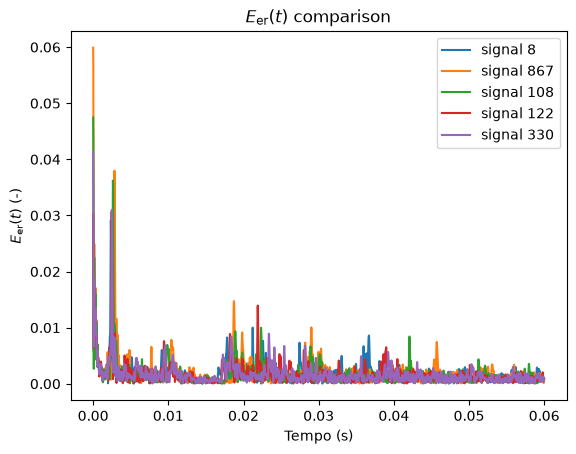

In [50]:
t = ykk.tvec(_60ms,fs)
for idx in (np.random.rand(5)*echogram.shape[0]).astype(int):
    plt.plot(t,Eer[idx,:],label=f'signal {idx}')

plt.title(r'$E_\text{er}(t)$ comparison')
plt.xlabel('Tempo (s)')
plt.ylabel(r'$E_\text{er}(t)$ (-)')
plt.legend()